In [1]:
import os
os.chdir('..')

In [2]:
from thefuzz import process
import cn2an
import logging
import re
from utils import pre_process, pre_process_without_n, printWithColor
import pandas as pd
import matplotlib.pyplot as plt
plt.rcParams['font.family'] = ['Heiti TC']  

In [3]:
def find_设置特定期限_rule_base(docs):
    # Ignore the warnings
    logging.getLogger().setLevel(logging.ERROR)
    
    # Define the keywords pattern
    keywords = [
        "(?:^|,)\s*本办法自.*?有效期",
        "(在|于)(年|月|日)前",
        "(至|到).*?(年|月|日)为止",
        "为期","巡查时期","时间进度","个工作日内","个月内","年内"
    ]
    pattern = re.compile('|'.join(keywords))
    
    # Process the document to separate it into paragraphs
    paragraphs = pre_process(docs)
    matched_paragraphs = []
    
    # First loop: Search for matches in each paragraph
    for paragraph in paragraphs:
        if pattern.search(paragraph):
            matched_paragraphs.append((paragraph.strip(), pattern.search(paragraph).group()))
        else:
            continue
        
    # Second loop: Find the indices of matched paragraphs in the original document
    matched_paragraphs_index = []
    for sentence in matched_paragraphs:
        begin_index = docs.find(sentence[0])
        end_index = begin_index + len(sentence[0])
        matched_paragraphs_index.append((begin_index, end_index))
        
    return matched_paragraphs, matched_paragraphs_index


## Demonstration for using find_设置特定期限_rule_base() function ##

$\textbf{We first read .txt file randomly from samples folder}$

In [4]:
file_sample = os.listdir('sample')[2]
docs = open(f'sample/{file_sample}', 'r').read()
matched_paragraphs, matched_paragraphs_index = find_设置特定期限_rule_base(docs)

$\textbf{We can now check the content that we retrieved from the file and its corresponding reasons.}$

In [5]:
pd.set_option('display.max_colwidth', None)
df = pd.DataFrame(matched_paragraphs, columns=['Retrieve Info', 'Reason'])
df.head(10)

,Retrieve Info,Reason
0,（3）公安机关自受理材料之日起35个工作日内完成审核工作，如需请示上级部门的，请示期间不计入办理时限；,个工作日内
1,（4）符合迁入“公共户”条件的，公安机关通知申请人自通知之日起10个工作日内办理迁入手续,个工作日内
2,“公共户”户内人员应在《常住人口登记卡》到期前14个工作日内到户籍地派出所申请换发新的《常住人口登记卡》；,个工作日内
3,“公共户”户内人员本人应在到期前14个工作日内前往户籍所在地派出所申请换发新的《常住人口登记卡》,个工作日内


$\textbf{We can also check where is the sentence}$

In [6]:
printWithColor(docs, matched_paragraphs_index)

    【法宝引证码】 CLI.12.4083221
原文链接：https://www.pkulaw.com/lar/3240473cf3cb645ddb9699ac8ed6ea7dbdfb.html
北京市公安局关于印发户籍派出所设立公共户工作规定(试行)的通知
北京市公安局关于印发户籍派出所设立公共户工作规定（试行）的通知

（京公人口基层字〔2021〕473号）

各分局：

　　为有效解决暂不具备市内迁移条件的本市户籍人员落户问题，经第5次市局局长办公会通过，现将《北京市公安局户籍派出所设立公共户工作规定（试行）》印发给你们，请认真贯彻执行。

　　附件：1.《告知书》及《告知书回执》

　　2.《迁入“公共户”承诺书》

　　3.《房屋所有权人或公有住房承租人申请迁移滞留户口人员承诺书》
北京市公安局

　　2021年5月28日
北京市公安局户籍派出所设立公共户工作规定（试行）

　　为推动户籍管理工作理念和机制创新，有效解决暂不具备市内迁移条件的本市户籍人员落户问题，依据《中华人民共和国户口登记条例》、《派出所办理常住户口登记工作规范（试行）》等法规政策，北京市公安局经充分调研，在广泛征求意见基础上，决定在全市户籍派出所设立“公共户”，具体规定如下：
　　一、“公共户”设立

　　全市每个户籍派出所原则上只设立一个非农业“公共户”，接收暂不具备市内迁移条件的本辖区非农业户口人员落户。
　　二、“公共户”落户条件

　　符合下列情形之一的我市户籍人员（不含学生户口、驻京办户口、博士后户口等限制市内户口迁移人员），可以在户籍所在地派出所申请“公共户”落户：

　　（一）因房屋产权交易户口须迁出，但本人、配偶或其他直系亲属（其他直系亲属包含父母、子女、（外）祖父母、（外）孙子女。下同）在本市无合法产权住房，户口无法迁出的；

　　（二）因离婚后户口须迁出，但本人、配偶或其他直系亲属在本市无合法产权住房，户口无法迁出的；

　　（三）因离职户口须从原单位集体户迁出，现单位无集体户，且本人、配偶或其他直系亲属在本市无合法产权住房，户口无法迁出的；

　　（四）因房屋交易所有权变更或者公有住房承租权变更，现房屋权利人申请将原户内人员迁出的，原户内人员无正当理由拒不迁出的；

　　（五）新生儿亲生父母一方户口在本市“公共户”内，且新生儿无法在本市其他地址申报出生登记的

## Now we can run batch processing on our sample data ##

In [7]:
def run_batch(path_to_folder):
    return_df = pd.DataFrame(columns=['filename', 'Retrieve Info', 'Reason', 'Original Text Length','Retrieve Info Length'])
    files = os.listdir(path_to_folder)
    for file in files:
        if not file.endswith('.txt'):
            continue
        docs = open(f'{path_to_folder}/{file}', 'r').read()
        matched_paragraphs, matched_paragraphs_index = find_设置特定期限_rule_base(docs)
        matched_paragraphs_list = "\n".join([paragraph[0] for paragraph in matched_paragraphs])
        reson_list = "\n".join([paragraph[1] for paragraph in matched_paragraphs])
        
        return_df.loc[len(return_df)] = [file, matched_paragraphs_list , reson_list, len(docs), len(matched_paragraphs_list)]
    
    return return_df


In [8]:
df = run_batch('sample')
# we chack first 5 files
df.head(5)
# you can save this to csv
# df.to_csv('path/to/your/result.csv', index=False)

,filename,Retrieve Info,Reason,Original Text Length,Retrieve Info Length
0,佛山市人力资源和社会保障局关于新增血友病(...(FBM-CLI.12.6305146).txt,,,558,0
1,吉林省工业和信息化厅关于转发《工业和信息化...(FBM-CLI.12.1054681).txt,,,1088,0
2,北京市公安局关于印发户籍派出所设立公共户工...(FBM-CLI.12.4083221).txt,（3）公安机关自受理材料之日起35个工作日内完成审核工作，如需请示上级部门的，请示期间不计入办理时限；\n（4）符合迁入“公共户”条件的，公安机关通知申请人自通知之日起10个工作日内办理迁入手续\n“公共户”户内人员应在《常住人口登记卡》到期前14个工作日内到户籍地派出所申请换发新的《常住人口登记卡》；\n“公共户”户内人员本人应在到期前14个工作日内前往户籍所在地派出所申请换发新的《常住人口登记卡》,个工作日内\n个工作日内\n个工作日内\n个工作日内,4274,199
3,淄博市文化和旅游局对市政协十二届五次会议委...(FBM-CLI.12.5629955).txt,,,1298,0
4,广西壮族自治区文化和旅游厅办公室关于印发《...(FBM-CLI.12.3014292).txt,,,613,0


$\textbf{Here we provide some statistics on the results}$

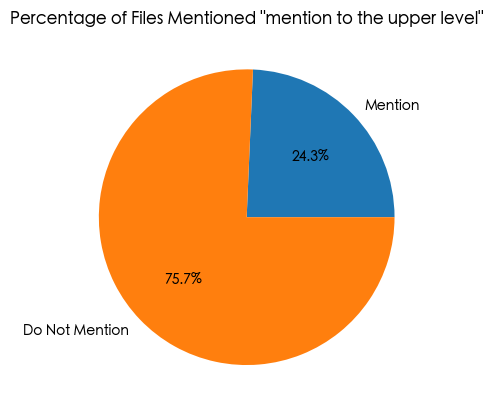

In [9]:
# We can show how many files have the retrieve info
is_mention = len(df[df['Retrieve Info'] != ''])
do_not_mention = len(df[df['Retrieve Info'] == ''])

fig, ax = plt.subplots()
ax.pie([is_mention, do_not_mention], labels=['Mention', 'Do Not Mention'], autopct='%1.1f%%')
plt.title('Percentage of Files Mentioned "mention to the upper level"')
plt.show()


$\textbf{To analyze the results of retrieval text, we need to remove the policy that do not have retrieval info}$

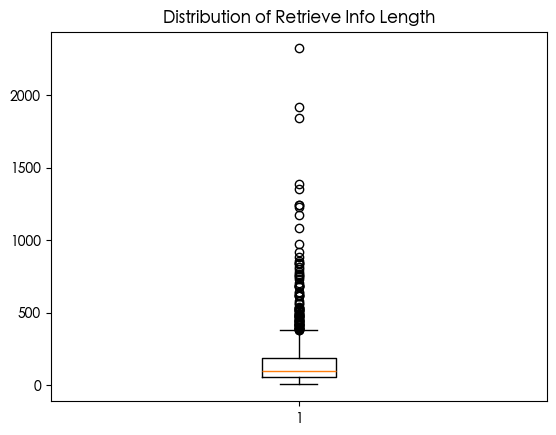

In [10]:
# Box plot to show the distribution of retrieve info length
df_temp = df.copy()
# we drop all the rows that do not have retrieve info
df_temp = df_temp[df_temp['Retrieve Info'] != '']
retrieve_info_length = df_temp['Retrieve Info'].apply(lambda x: len(x))
plt.boxplot(retrieve_info_length)
plt.title('Distribution of Retrieve Info Length')
plt.show()

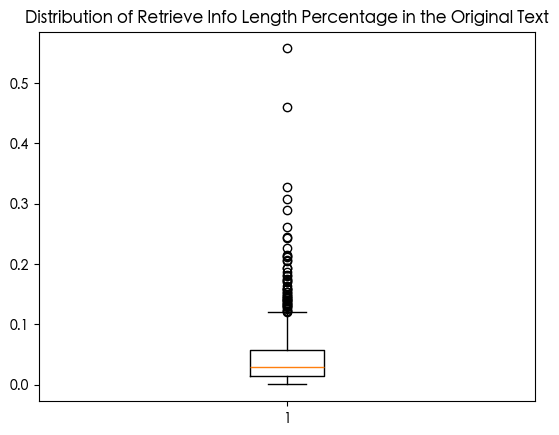

In [11]:
# we can also see the distribution that to what percentage of the document is the retrieve info
df_temp['Retrieve Info Length Percentage'] = df_temp['Retrieve Info Length'] / df_temp['Original Text Length']
plt.boxplot(df_temp['Retrieve Info Length Percentage'])
plt.title('Distribution of Retrieve Info Length Percentage in the Original Text')
plt.show()

In [12]:
# let's show the most three outliar for the retrieve info length
df_temp.sort_values('Retrieve Info Length', ascending=False).head(3)

,filename,Retrieve Info,Reason,Original Text Length,Retrieve Info Length,Retrieve Info Length Percentage
1788,安徽省交通运输厅关于2021―2022年度农村公路灾毁保...(FBM-CLI.12.4065139).txt,主承保人承诺完成定损并达成赔偿协议后，对应县（市、区）分支机构按以下时效进行赔付：赔款金额在5万元以下，1个工作日内赔付；赔款金额在5万元及以上，3个工作日内赔付\n对于需要委托公估处理的案件，在我公司初步查勘后半个工作日内通知公估，公估公司应在1个工作日内到达出险现场作调查取证工作\n单证审核接报案后1个工作日内，向被保险人提交《索赔指引及清单》\n我公司在收到索赔资料1个工作日内未书面提出有关审查核实意见，视为认可索赔资料完整\n核损理算（1）估损金额在5万元（含）以下的赔案，应在1个工作日内完成定损；（2）估损金额在5万元-20万元（含）的赔案，应在2个工作日内完成定损；（3）估损金额在20万元以上的赔案，应在3个工作日内完成定损；（4）若保险人在上述时间内未提出书面异议，视为双方就赔偿结果达成一致\n预付赔款接到预付赔款申请1个工作日内，就预付时间、金额做出书面回复\n当发生保险责任范围内的损失（估损金额在人民币10万元（含）以上）事故后，按估损金额的50%作为预付赔款金额，并在5个工作日内完成批复和支付手续，便于被保险人及时恢复生产\n赔款支付核损方为人保财险：（1）人民币5万元（含）以下赔案结案后，1个工作日内支付\n对于需要委托公估处理的案件，在主承保人初步查勘后半个工作日内通知公估，公估公司应在1个工作日内到达出险现场作调查取证工作\n1）预估损失在5万元（含）以下的保险事故，保险人应在1个工作日内完成定损；\n2）预估损失在5万元以上20万元以下（含），保险人应在2个工作日内完成定损；\n3）预估损失在20万元以上，以及重大、疑难案件保险人均应在3个工作日内完成定损； 对认定不属于保险责任的，主承保人分支机构将在自作出核定之日起三日内向被保险人发出拒绝赔偿或者拒绝给付保险金通知书，并说明理由\n在接到索赔资料后，主承保人应立即审查核实， 若认为有关证明和材料不完整，应立即一次性通知被保险人应补充提供的有关证明或资料， 若在接到索赔资料后1个工作日内未提出有关审核意见，则视为认可索赔资料完整\n被保险人索赔资料提供完整后，主承保人分支机构应迅速处理，在3个工作日内完成理算工作并以书面形式向被保险人提出定责定损意见\n1）赔款金额在5万元以下，1个工作日内赔付完成；\n2）赔款金额在5万元及以上，3个工作日内赔付完成\n对于确属保险责任，且一次事故双方确认的估损金额在 10 万元（含）以上的，主承保人预付 50%赔款，并在 5 个工作日内完成批复和支付手续，其余赔款按合同约定赔付\n如乙方在甲方规定的时间内未能提供符合质量标准的服务，甲方有权终止合同，没收履约保证金，提请政府采购监管部门将乙方列入不良行为记录名单，在一至三年内禁止参加政府采购活动\n如乙方在甲方规定的时间内未能提供符合质量标准的服务，甲方有权终止合同，没收履约保证金，提请政府采购监管部门将乙方列入不良行为记录名单，在一至三年内禁止参加政府采购活动\n（四）乙方将合同转包、擅自变更、中止或者终止合同的，甲方有权终止合同，并将提请政府采购监管部门对乙方进行采购金额千分之五的罚款，列入不良行为记录名单，在一至三年内禁止参加政府采购活动\n乙方出具好保险合同后，保费由***县级交通运输局在保险合同送达之日起15个工作日内支付\n对于需要委托公估处理的案件，在我公司初步查勘后半个工作日内通知公估，公估公司应在1个工作日内到达出险现场作调查取证工作\n单证审核接报案后1个工作日内，向被保险人提交《索赔指引及清单》\n我公司在收到索赔资料1个工作日内未书面提出有关审查核实意见，视为认可索赔资料完整\n核损理算（1）估损金额在5万元（含）以下的赔案，应在1个工作日内完成定损；（2）估损金额在5万元-20万元（含）的赔案，应在2个工作日内完成定损；（3）估损金额在20万元以上的赔案，应在3个工作日内完成定损；（4）若保险人在上述时间内未提出书面异议，视为双方就赔偿结果达成一致\n预付赔款接到预付赔款申请1个工作日内，就预付时间、金额做出书面回复\n当发生保险责任范围内的损失（估损金额在人民币10万元（含）以上）事故后，按估损金额的50%作为预付赔款金额，并在5个工作日内完成批复和支付手续，便于被保险人及时恢复生产\n赔款支付核损方为人保财险：（1）人民币5万元（含）以下赔案结案后，1个工作日内支付\n对于需要委托公估处理的案件，在主承保人初步查勘后半个工作日内通知公估，公估公司应在1个工作日内到达出险现场作调查取证工作\n1）预估损失在5万元（含）以下的保险事故，保险人应在1个工作日内完成定损；\n2）预估损失在5万元以上20万元以下（含），保险人应在2个工作日内完成定损；\n3）预估损失在20万元以上，以及重大、疑难案件保险人均应在3个工作日内完成定损； 对认定不属于保险责任的，主承保人分支机构将在自作出核定之日起三日内向被保险人发出拒绝赔偿或者拒绝给付保险金通知书，并说明理由\n在接到索赔资料后，主承保人应立即审查核实， 若认为有关证明和材料不完整，应立即一次性通知被保险人应补充提供的有关证明或资料， 若在接到索赔资料后1个工作日内未提出有关审核意见，则视为认可索赔资料完整\n被保险人索赔资料提供完整后，主承保人分支机构应迅速处理，在3个工作日内完成理算工作并以书面形式向被保险人提出定责定损意见\n1）赔款金额在5万元以下，1个工作日内赔付完成；\n2）赔款金额在5万元及以上，3个工作日内赔付完成\n对于确属保险责任，且一次事故双方确认的估损金额在 10 万元（含）以上的，主承保人预付 50%赔款，并在 5 个工作日内完成批复和支付手续，其余赔款按合同约定赔付,个工作日内\n个工作日内\n个工作日内\n个工作日内\n个工作日内\n个工作日内\n个工作日内\n个工作日内\n个工作日内\n个工作日内\n个工作日内\n个工作日内\n个工作日内\n个工作日内\n个工作日内\n个工作日内\n个工作日内\n年内\n年内\n年内\n个工作日内\n个工作日内\n个工作日内\n个工作日内\n个工作日内\n个工作日内\n个工作日内\n个工作日内\n个工作日内\n个工作日内\n个工作日内\n个工作日内\n个工作日内\n个工作日内\n个工作日内\n个工作日内\n个工作日内,29524,2321,0.078614
3501,广东省卫生健康委关于全面推开公共场所卫生许...(FBM-CLI.12.1541523).txt,行政审批机关应当在作出准予行政审批的决定后2个月内，对被审批人的承诺内容是否属实进行检查核实\n（五） 50个房间以上的住宿场所、游泳场所、安装集中式空调通风系统的场所提供一年内具有资质的检测机构出具的、符合《旅店业卫生标准》（GB9663）、《公共场所卫生检验方法第1-第6部分》（GB/T18204）和《公共场所集中空调通风系统卫生规范》（WS394-2012）要求的卫生检测检验报告或卫生学评价报告（含集中空调通风系统卫生检验检测报告或卫生学评价报告）；\n申请人愿意作出承诺的，应在收到本告知承诺书之日起2个月内达到承诺的条件\n〔本行政审批机关，将在作出准予行政审批决定后2个月内对申请人的承诺内容是否属实进行检查\n（五）游泳场所、安装集中式空调通风系统的场所提供一年内具有资质的检测机构出具的、符合《游泳场所卫生标准》（GB9667）、《公共场所卫生检验方法第1-第6部分》（GB/T18204）和《公共场所集中空调通风系统卫生规范》（WS394-2012）要求的卫生检测检验报告或卫生学评价报告（含集中空调通风系统卫生检验检测报告或卫生学评价报告）\n申请人愿意作出承诺的，应在收到本告知承诺书之日起2个月内达到承诺的条件\n〔本行政审批机关，将在作出准予行政审批决定后2个月内对申请人的承诺内容是否属实进行检查\n（五） 安装集中式空调通风系统的场所提供一年内具有资质的检测机构出具的、符合《公共场所集中空调通风系统卫生规范》（WS394-2012）和《公共场所卫生检验方法第1-第6部分》（GB/T18204）要求的卫生检测检验报告或卫生学评价报告（含集中空调通风系统卫生检验检测报告或卫生学评价报告）\n申请人愿意作出承诺的，应在收到本告知承诺书之日起2个月内达到承诺的条件\n〔本行政审批机关，将在作出准予行政审批决定后2个月内对申请人的承诺内容是否属实进行检查\n（五） 安装集中式空调通风系统的场所提供一年内具有资质的检测机构出具的、符合《公共场所集中空调通风系统卫生规范》（WS394-2012）和《公共场所卫生检验方法第1-第6部分》（GB/T18204）要求的卫生检测检验报告或卫生学评价报告（含集中空调通风系统卫生检验检测报告或卫生学评价报告）；\n申请人愿意作出承诺的，应在收到本告知承诺书之日起2个月内达到承诺的条件\n〔本行政审批机关，将在作出准予行政审批决定后2个月内对申请人的承诺内容是否属实进行检查\n（五） 安装集中式空调通风系统的场所提供一年内具有资质的检测机构出具的、符合《公共场所集中空调通风系统卫生规范》（WS394-2012）和《公共场所卫生检验方法第1-第6部分》（GB/T18204）要求的卫生检测检验报告或卫生学评价报告（含集中空调通风系统

In [13]:
# we can also show the most three outliar for the retrieve info length percentage
df_temp.sort_values('Retrieve Info Length Percentage', ascending=False).head(3)

,filename,Retrieve Info,Reason,Original Text Length,Retrieve Info Length,Retrieve Info Length Percentage
3778,宁夏回族自治区财政厅、自治区国税局、自治区...(FBM-CLI.12.1244704).txt,1.对自主就业退役士兵从事个体经营的，3年内按每户每年9600元为限额依次扣减其当年实际应缴纳的增值税、城市维护建设税、教育费附加、地方教育附加和个人所得税；\n2.对我区商贸企业、服务型企业、劳动就业服务企业中的加工型企业和街道社区具有加工性质的小型企业实体，在新增加的岗位中，当年新招用自主退役士兵，与其签订1年以上期限劳动合同并依法缴纳社会保险费的，在3年内按实际招用人数，按每人每年6000元定额标准依次扣减增值税、城市维护建设税、教育费附加、地方教育附加和企业所得税\n3.对持《就业创业证》（注明“自主创业税收政策”或“毕业年度内自主创业税收政策”）或2015年1月27日前取得的《就业失业登记证》（注明“自主创业税收政策”或附着《高校毕业生自主创业证》）的人员从事个体经营的，在3年内按每户每年9600元为限额依次扣减其当年实际应缴纳的增值税、城市维护建设税、教育费附加、地方教育附加和个人所得税；\n4.对我区商贸企业、服务型企业、劳动就业服务企业中的加工型企业和街道社区具有加工性质的小型企业实体，在新增加的岗位中，当年新招用在人力资源社会保障部门公共就业服务机构登记失业半年以上且持有《就业创业证》或2015年1月27日前取得的《就业失业登记证》（注明“企业吸纳税收政策”）人员，与其签订1年以上期限劳动合同并依法缴纳社会保险费的，在3年内按实际招用人数按每人每年5200元定额标准依次扣减增值税、城市维护建设税、教育费附加、地方教育附加和企业所得税,年内\n年内\n年内\n年内,1134,632,0.557319
2643,广西壮族自治区财政厅、广西壮族自治区地方税...(FBM-CLI.12.539901).txt,根据《财政部 国家税务总局关于支持和促进就业有关税收政策的通知》（财税〔2010〕84号）规定，经自治区人民政府同意，我区对商贸企业、服务型企业（除广告业、房屋中介、典当、桑拿、按摩、氧吧处）、劳动就业服务企业中的加工型企业和街道社区具有加工性质的小型企业实体，在新增加的岗位中，当年新招用持《就业失业登记证》（注明“企业吸纳税收政策”）人员，与其签订1年以上期限劳动合同并依法缴纳社会保险费的，在3年内按实际招用人数予以定额依次扣减营业税、城市维护建设税、教育费附加和企业所得税的定额标准在每人每年4000元基础上上浮动20%，即按4800元执行,年内,596,274,0.459732
821,新疆生产建设兵团关于印发《加快专项资金预算...(FBM-CLI.12.1564388).txt,1. 中央财政下达的专项资金，明确项目和分配标准的，项目主管部门自收到文件起7个工作日内提出分配意见，财政部门3个工作日内下达通知，并编入兵团预算草案\n2. 中央财政切块下达需要再次分配的，除中央财政明确按项目法分配的外，项目主管部门自收到文件起原则上按因素法10个工作日内提出资金分配意见，报项目主管部门兵团分管领导批示后，财政部门3个工作日内下达通知，并编入兵团预算草案\n1. 明确项目或分配标准的，项目主管部门7个工作日内提出分配意见，财政部门3个工作日内下达资金；\n2. 对没有明确项目或分配标准、属于历年安排的专项资金，有资金管理办法且使用范围明确、数额固定的，由项目主管部门10个工作日内提出分配意见，报项目主管部门的兵团分管领导批示后，财政部门3个工作日内下达师市，1亿元（含1亿元）以上的形成请示件报备兵团党委（财经委员会）；\n3. 新增加的专项，除兵团明确按项目法分配外，主管部门原则上按照因素法一个月内提出分配意见，1亿元以下的事项，报兵团行政常务会会议审定后，财政部门立即拨付资金，并形成请示件报备兵团党委（财经委员会）；1亿元以上（含1亿元）的事项，兵团行政常务会会议审议通过后，报兵团党委常委会审定后，财政部门立即拨付资金,个工作日内\n个工作日内\n个工作日内\n个工作日内\n个月内,1596,524,0.328321


## We can also comparing the statistics results between different labels in our sample by aggrigate the labels from task B ##

In [14]:
df_label = pd.read_csv('policies_label.csv')
df_all = df.join(on='filename', how = 'inner', other = df_label.set_index('filename'))

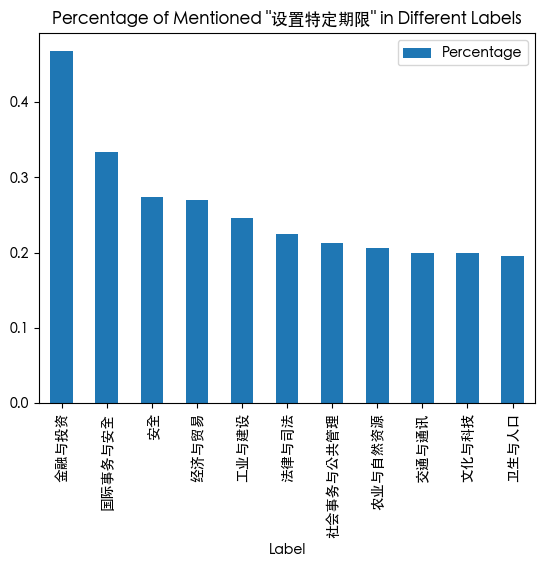

In [15]:
# we use l1 to aggregate the result
agg_result = etrieve_info_length = df_all.groupby('label_L1')

data = []
for name, group in agg_result:
    total = group['Retrieve Info Length'].count()
    mention = group[group['Retrieve Info Length'] != 0]['Retrieve Info Length'].count()
    data.append((name, mention, total, mention/total))

data.sort(key=lambda x: x[3], reverse=True)

# plot the result so we can see the percentage of the mention in different labels
df_plot = pd.DataFrame(data, columns=['Label', 'Mention', 'Total', 'Percentage'])
df_plot.plot(x='Label', y='Percentage', kind='bar')
plt.title('Percentage of Mentioned "设置特定期限" in Different Labels')
plt.xticks(rotation=90)
plt.show()

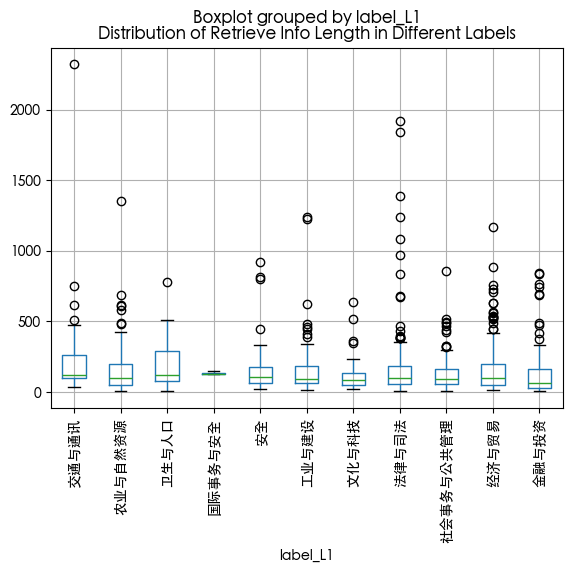

In [16]:
# we can also plot box plot to show the distribution of retrieve info length in different labels
df_temp = df_all.copy()
# we drop all the rows that do not have retrieve info
df_temp = df_temp[df_temp['Retrieve Info'] != '']
df_temp.boxplot(column='Retrieve Info Length', by='label_L1')
plt.title('Distribution of Retrieve Info Length in Different Labels')
plt.xticks(rotation=90)
plt.show()

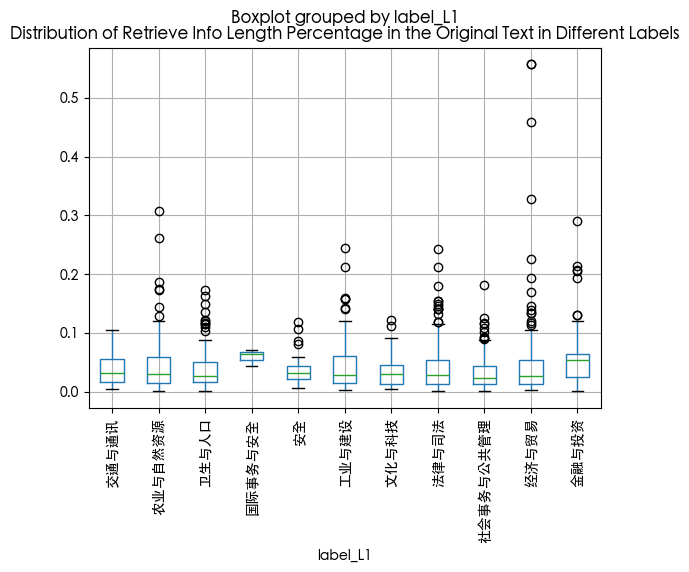

In [17]:
# we can also show the distribution that to what percentage of the document is the retrieve info in different labels
df_temp['Retrieve Info Length Percentage'] = df_temp['Retrieve Info Length'] / df_temp['Original Text Length']
df_temp.boxplot(column='Retrieve Info Length Percentage', by='label_L1')
plt.title('Distribution of Retrieve Info Length Percentage in the Original Text in Different Labels')
plt.xticks(rotation=90)
plt.show()